# Underwriting Credit Risk Analysis

**Objective:**  
This project simulates a commercial bank underwriting workflow using borrower-level loan data. The analysis evaluates repayment capacity, identifies key drivers of default risk, segments borrowers into practical risk tiers, builds a probability-of-default (PD) model, and applies a simple underwriting decision framework aligned with real-world credit risk decisioning.

**Business Context:**  
In commercial and consumer lending, underwriters assess whether a borrower has the financial strength and credit profile to repay a loan under reasonable stress. This project mirrors that process by combining borrower capacity metrics, risk segmentation, and model-based probability estimates to support **Approve / Manual Review / Reject** decisions.

**Core Questions:**
- Which borrower characteristics are most associated with default risk?
- How does repayment capacity affect underwriting outcomes?
- Can a simple PD model separate lower-risk and higher-risk applicants?
- How can model outputs be translated into practical credit decisions?

---

## 1. Import Packages and Load Data

In [52]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay

# import data
df_raw = pd.read_csv('../data/credit_risk_dataset.csv')
df_raw.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Data Understanding & Cleaning

### 2.1 Initial Data Inspection

The first step in any underwriting analysis is to understand the structure and quality of the dataset before drawing any conclusions. In this section, I review the dataset’s dimensions, variable types, missing values, and basic summary statistics to identify issues that could distort risk analysis or model performance.

From an underwriting perspective, this step is important because messy or unrealistic values can lead to misleading conclusions about borrower strength, portfolio quality, and default behavior. A clean and well-understood dataset is essential before building risk metrics or predictive models.

In [11]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


**Interpretation:**  
The dataset includes a mix of numeric and categorical borrower attributes, which is consistent with real underwriting data. This initial review helps confirm which fields can be used directly, which require cleaning, and which will need transformation before modeling.

In [18]:
object_cols = df_raw.select_dtypes(include='object').columns
for col in object_cols:
    print(f"Unique values in '{col}': {df_raw[col].unique()}")

Unique values in 'person_home_ownership': ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
Unique values in 'loan_intent': ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
Unique values in 'loan_grade': ['D' 'B' 'C' 'A' 'E' 'F' 'G']
Unique values in 'cb_person_default_on_file': ['Y' 'N']


**Interpretation:**  
Reviewing unique categorical values helps validate whether the portfolio fields are consistent and usable for analysis. This is especially important for underwriting because variables such as home ownership, loan intent, and prior default history often carry meaningful risk signals.

In [19]:
# initial data exploration
missing_summary = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "dtype": df_raw.dtypes
}).sort_values("missing_pct", ascending=False)

print("Missing values summary:")
display(missing_summary)

print("Descriptive statistics:")
display(df_raw.describe().T)

Missing values summary:


,missing_count,missing_pct,dtype
loan_int_rate,3116,9.56,float64
person_emp_length,895,2.75,float64
person_age,0,0.00,int64
person_income,0,0.00,int64
person_home_ownership,0,0.00,object
loan_intent,0,0.00,object
loan_grade,0,0.00,object
loan_amnt,0,0.00,int64
loan_status,0,0.00,int64
loan_percent_income,0,0.00,float64


Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


**Interpretation:**  
The missing value review highlights where imputation may be needed, while the descriptive statistics help identify possible outliers or unrealistic borrower values. In lending analysis, these checks are important because extreme values can distort default comparisons and weaken model stability.

### 2.2 Data Cleaning

Credit datasets often contain unrealistic values, outliers, or incomplete fields that are not suitable for direct underwriting analysis. In this section, I apply practical cleaning steps to improve data quality while preserving the underlying risk patterns in the portfolio.

The cleaning approach is intentionally simple and underwriting-oriented:
- remove clearly unrealistic borrower ages,
- cap extreme income and loan values to reduce outlier distortion,
- limit employment length to a realistic range,
- retain missing interest rates for later imputation in the modeling pipeline.

These steps help ensure that the analysis reflects realistic borrower behavior rather than data-entry anomalies.

In [ ]:
df = df_raw.copy()

# Remove rows with unrealistic ages
df = df[(df['person_age'] >= 18) & (df['person_age'] <= 100)]

# Winsorize extreme values in income and loan amount
for col in ['person_income', 'loan_amnt']:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

# Cap employment length at 40 years
df['person_emp_length'] = df['person_emp_length'].clip(upper=40)

# Clean impossible interest rates but keep NaN values for imputation
df.loc[(df["loan_int_rate"] <= 0) | (df["loan_int_rate"] >= 40), "loan_int_rate"] = np.nan

print("Original dataset shape:", df_raw.shape)
print("Cleaned dataset shape:", df.shape)

Original dataset shape: (32581, 12)
Cleaned dataset shape: (32576, 12)


**Interpretation:**  
The cleaning process preserves nearly all observations while reducing noise from implausible values. This improves the reliability of downstream risk comparisons and makes the portfolio more suitable for underwriting analysis and PD modeling.

## 3. Feature Engineering

Underwriting decisions are rarely based on raw fields alone. Credit analysts typically derive additional metrics that better reflect repayment capacity, leverage, and historical credit behavior. In this section, I create underwriting-style features that make the borrower profile more interpretable and more useful for risk segmentation and PD modeling.

Key engineered variables include:
- **Loan-to-Income Ratio (LTI):** a proxy for repayment burden relative to borrower income,
- **Prior Default Flag:** a simplified indicator of past derogatory credit behavior,
- **Numeric Loan Grade:** an ordered representation of credit quality,
- **Interest Burden as % of Income:** a rough affordability measure,
- **Risk Tier:** a practical segmentation based on LTI thresholds.

These features are designed to reflect how underwriters translate application data into actionable risk signals.

In [ ]:
# loan-to-income ratio
df['loan_to_income'] = df['loan_amnt'] / df['person_income']

# Prior default flag
df["prior_default_flag"] = (df["cb_person_default_on_file"].str.upper() == "Y").astype(int)

# Convert loan grade to ordered numeric scale
grade_map = {grade: i for i, grade in enumerate(list("ABCDEFG"), start=1)}
df["loan_grade_num"] = df["loan_grade"].map(grade_map)

# Approximate interest burden as % of income
df["interest_burden_pct_income"] = (
    df["loan_amnt"] * (df["loan_int_rate"] / 100)
) / df["person_income"]

# Risk tiers based on Loan-to-Income Ratio
def assign_risk_tier(lti):
    if pd.isna(lti):
        return "Unknown"
    elif lti < 0.15:
        return "Low Risk"
    elif lti < 0.35:
        return "Medium Risk"
    else:
        return "High Risk"

df["risk_tier"] = df["loan_to_income"].apply(assign_risk_tier)

## 4. Exploratory Credit Risk Analysis

This section compares defaulted and non-defaulted borrowers to identify the financial and credit characteristics most associated with risk. The goal is to move beyond raw descriptive statistics and uncover the borrower patterns that matter most for underwriting decisions.

From a credit perspective, this analysis focuses on three core themes:
1. **Repayment capacity** — whether lower income or higher debt burden is associated with default,
2. **Exposure size** — whether larger loans lead to higher risk,
3. **Borrower quality** — whether defaulted borrowers differ meaningfully in affordability and credit history.

These insights help validate whether the engineered underwriting metrics are economically sensible before they are used in segmentation or modeling.

In [25]:
target = "loan_status"
print("Overall default rate: {:.2f}%".format(df[target].mean() * 100))

Overall default rate: 21.82%


**Interpretation:**  
The overall default rate provides a baseline view of portfolio risk and serves as a reference point for all later comparisons. Subsequent segments and model outputs can be evaluated against this benchmark to determine whether they capture meaningful risk differentiation.

In [26]:
# Compare defaulted vs non-defaulted borrowers
comparison_cols = [
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "loan_to_income",
    "interest_burden_pct_income",
    "cb_person_cred_hist_length"
]

default_comparison = df.groupby(target)[comparison_cols].agg(["mean", "median"]).round(2)
display(default_comparison)

person_income          person_emp_length        loan_amnt          \
                     mean   median              mean median      mean  median   
loan_status                                                                     
0                68732.19  60000.0              4.97    4.0   9208.95  8000.0   
1                48505.96  41498.0              4.13    3.0  10799.98  9600.0   

            loan_int_rate        loan_percent_income        loan_to_income  \
                     mean median                mean median           mean   
loan_status                                                                  
0                   10.44  10.59                0.15   0.13           0.15   
1                   13.06  13.49                0.25   0.24           0.25   

                   interest_burden_pct_income         \
            median                       mean median   
loan_status                                            
0             0.13                       0.02   0.01   
1             0.24                       0.03   0.03   

            cb_person_cred_hist_length         
                                  mean median  
loan_status                                    
0                                 5.84    4.0  
1                                 5.69    4.0

**Interpretation:**  
Defaulted borrowers generally show weaker financial profiles, including lower income, higher loan balances, and greater repayment burden. This suggests that affordability and leverage-related variables are likely to be important drivers of underwriting risk in this portfolio.

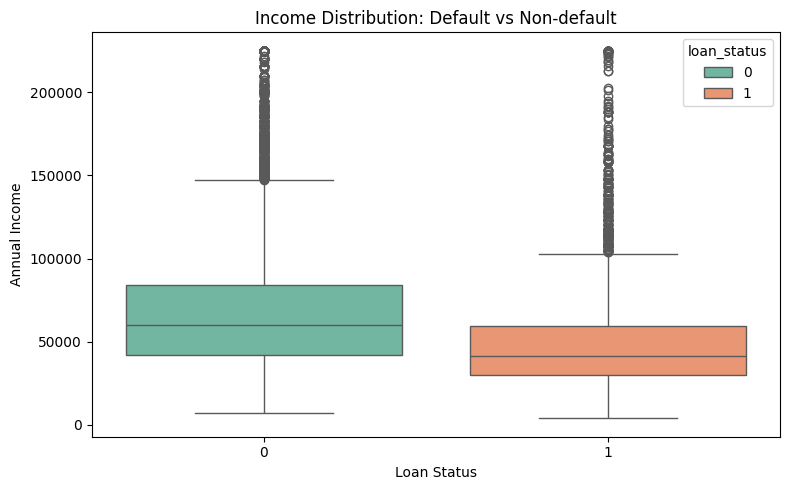

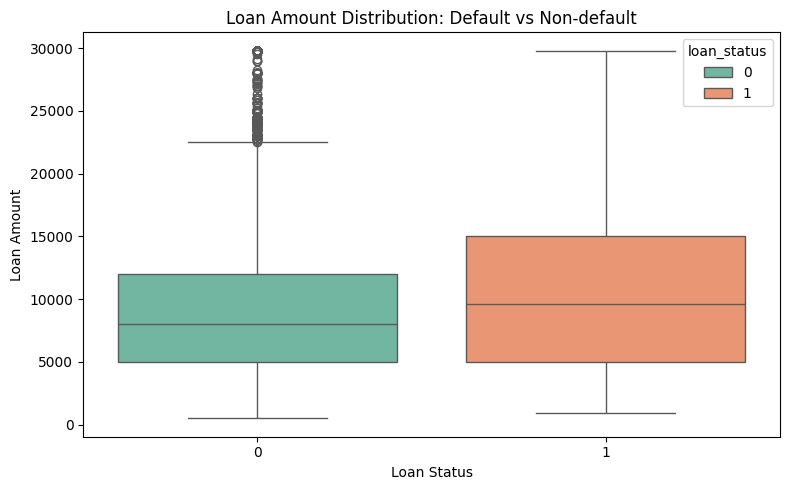

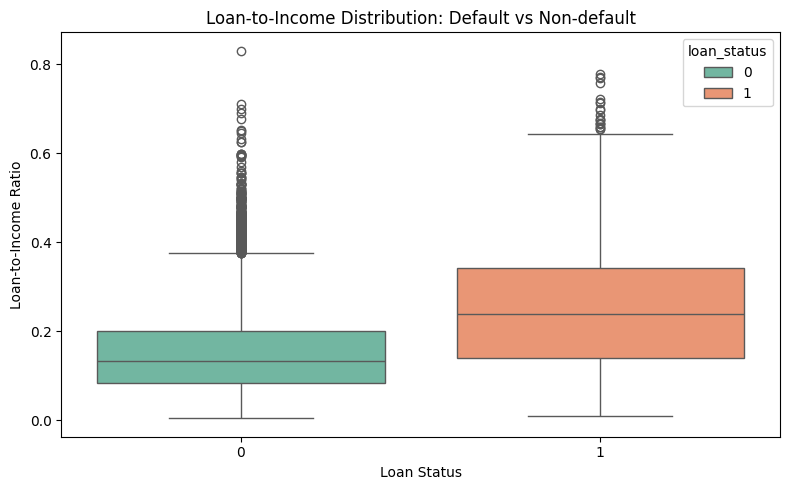

In [33]:
# Income distribution by default status
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=target, y="person_income", hue=target, palette="Set2")
plt.title("Income Distribution: Default vs Non-default")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")
plt.tight_layout()
plt.show()

# Loan amount distribution by default status
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=target, y="loan_amnt", hue=target, palette="Set2")
plt.title("Loan Amount Distribution: Default vs Non-default")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.tight_layout()
plt.show()

# Loan-to-income distribution by default status
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=target, y="loan_to_income", hue=target, palette="Set2")
plt.title("Loan-to-Income Distribution: Default vs Non-default")
plt.xlabel("Loan Status")
plt.ylabel("Loan-to-Income Ratio")
plt.tight_layout()
plt.show()

**Interpretation:**  
- Borrowers who defaulted tend to have lower income levels than borrowers who did not default. This supports the underwriting view that weaker repayment capacity is associated with higher credit risk.

- Defaulted borrowers appear to carry somewhat larger loan balances on average, indicating that exposure size may contribute to repayment stress. Larger requested loan amounts may therefore warrant closer review when not supported by strong income.

- The loan-to-income ratio shows clearer separation between defaulted and non-defaulted borrowers, suggesting it is one of the most informative underwriting metrics in the analysis. Higher borrower leverage relative to income is strongly associated with higher default risk.

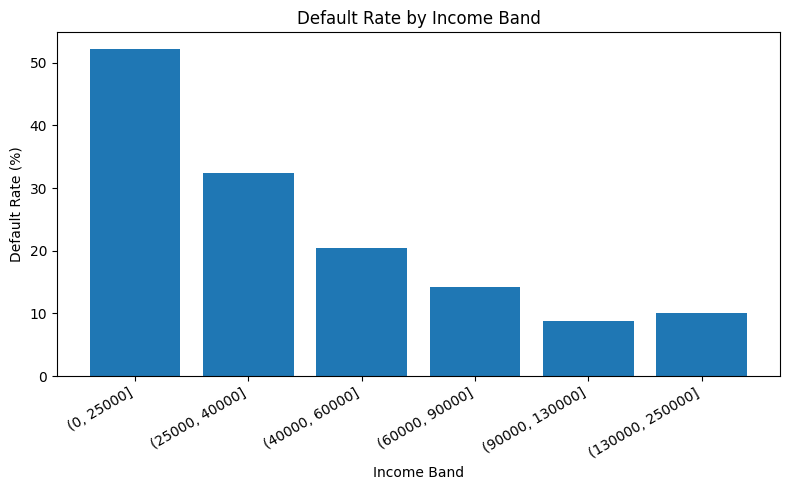

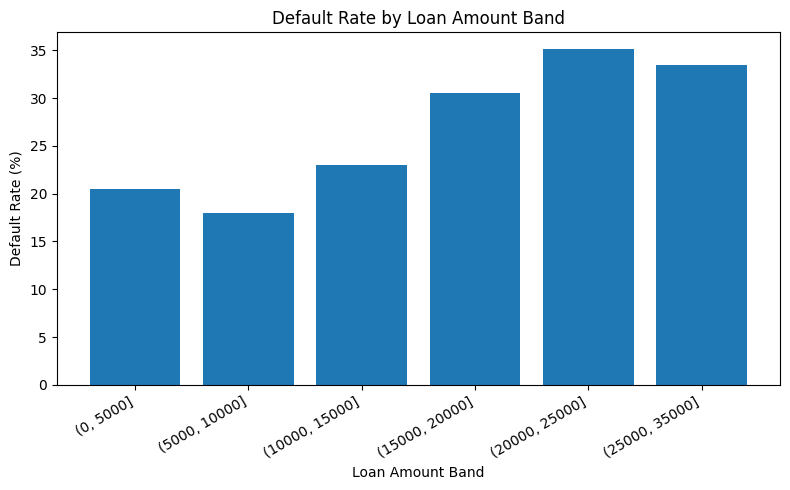

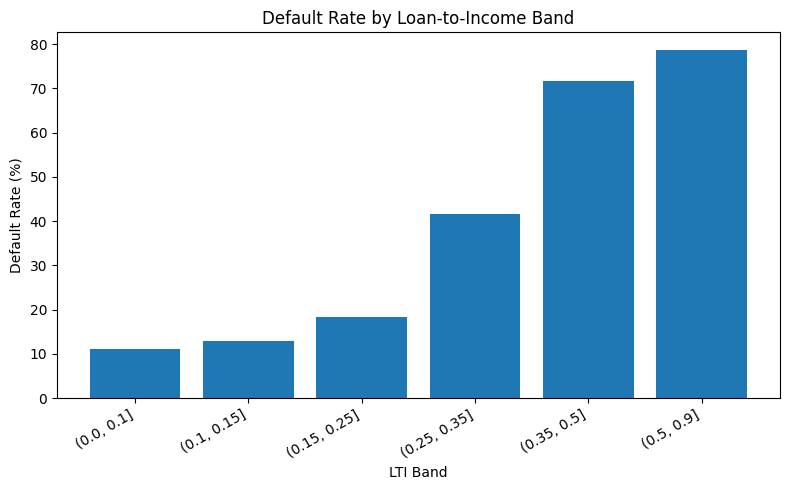

In [39]:
def default_rate_by_bins(df, column, bins):
    grouped = df.groupby(pd.cut(df[column], bins=bins))[target].agg(["count", "mean"])
    grouped["default_rate_pct"] = (grouped["mean"] * 100).round(2)
    return grouped

income_bins = [0, 25000, 40000, 60000, 90000, 130000, 250000]
loan_bins = [0, 5000, 10000, 15000, 20000, 25000, 35000]
lti_bins = [0, 0.10, 0.15, 0.25, 0.35, 0.50, 0.90]

income_default_tbl = default_rate_by_bins(df, "person_income", income_bins)
loan_default_tbl = default_rate_by_bins(df, "loan_amnt", loan_bins)
lti_default_tbl = default_rate_by_bins(df, "loan_to_income", lti_bins)

# Plot default rate by income band
plt.figure(figsize=(8, 5))
plt.bar(income_default_tbl.index.astype(str), income_default_tbl["default_rate_pct"])
plt.title("Default Rate by Income Band")
plt.xlabel("Income Band")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Plot default rate by loan amount band
plt.figure(figsize=(8, 5))
plt.bar(loan_default_tbl.index.astype(str), loan_default_tbl["default_rate_pct"])
plt.title("Default Rate by Loan Amount Band")
plt.xlabel("Loan Amount Band")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Plot default rate by LTI band
plt.figure(figsize=(8, 5))
plt.bar(lti_default_tbl.index.astype(str), lti_default_tbl["default_rate_pct"])
plt.title("Default Rate by Loan-to-Income Band")
plt.xlabel("LTI Band")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Interpretation:**  
- Default rates generally decline as borrower income increases, which is consistent with stronger repayment capacity among higher-income applicants. This suggests that income is an important stabilizing factor in credit performance.

- Default rates tend to rise as loan amounts become larger, especially in the upper exposure bands. This indicates that larger loans may create greater repayment stress when not supported by proportionately stronger borrower finances.

- Default risk rises sharply as loan-to-income increases, making LTI one of the clearest risk segmentation variables in the portfolio. This pattern supports using LTI thresholds as a practical underwriting rule for approval and escalation decisions.

## 5. Risk Segmentation

After identifying loan-to-income as a strong underwriting signal, I segment the portfolio into three practical risk tiers: **Low Risk**, **Medium Risk**, and **High Risk**. This mirrors how banks often translate continuous ratios into decision-oriented categories that can support policy rules, workflow triage, and credit committee discussions.

The purpose of this segmentation is to answer two questions:
- how much of the portfolio falls into each risk band,
- and whether those bands show meaningful differences in observed default rates.

If the segmentation is effective, higher-risk tiers should have materially worse outcomes than lower-risk tiers.

In [40]:
risk_summary = df["risk_tier"].value_counts().to_frame("borrower_count")
risk_summary["pct_of_portfolio"] = (risk_summary["borrower_count"] / len(df) * 100).round(2)

risk_default_summary = df.groupby("risk_tier")[target].mean().mul(100).round(2).to_frame("default_rate_pct")

risk_segmentation = risk_summary.join(risk_default_summary)
display(risk_segmentation)

,borrower_count,pct_of_portfolio,default_rate_pct
risk_tier,,,
Low Risk,16468,50.55,12.01
Medium Risk,13791,42.33,25.08
High Risk,2317,7.11,72.16


**Interpretation:**  
The risk-tier summary shows that the portfolio is not evenly distributed across borrower risk levels, and the observed default rates increase meaningfully as risk tier worsens. This confirms that the LTI-based segmentation is directionally useful for underwriting and portfolio screening.

## 6. PD Modeling

To complement rule-based underwriting metrics, I build a **logistic regression probability-of-default (PD) model** using borrower financial, credit, and application features. 

The model includes both numeric and categorical variables and uses a structured preprocessing pipeline:
- median imputation for numeric variables,
- most-frequent imputation for categorical variables,
- one-hot encoding for categorical features,
- standardization for numeric features.

In [48]:
feature_num = [
    "person_income",
    "person_emp_length",
    "cb_person_cred_hist_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_to_income",
    "interest_burden_pct_income",
    "loan_grade_num",
    "prior_default_flag"
]

feature_cat = [
    "person_home_ownership",
    "loan_intent"
]

X = df[feature_num + feature_cat]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, feature_num),
        ("cat", categorical_transformer, feature_cat)
    ]
)

model = LogisticRegression(
    solver="liblinear",
    max_iter=500
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Model Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Model ROC AUC: {:.4f}".format(roc_auc_score(y_test, y_prob)))

Model Accuracy: 0.8594
Model ROC AUC: 0.8687


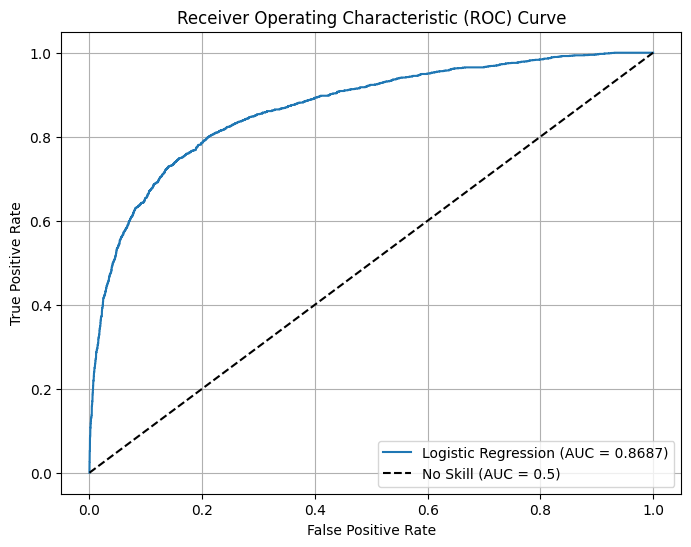

In [50]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='No Skill (AUC = 0.5)') # Diagonal baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


Confusion Matrix:


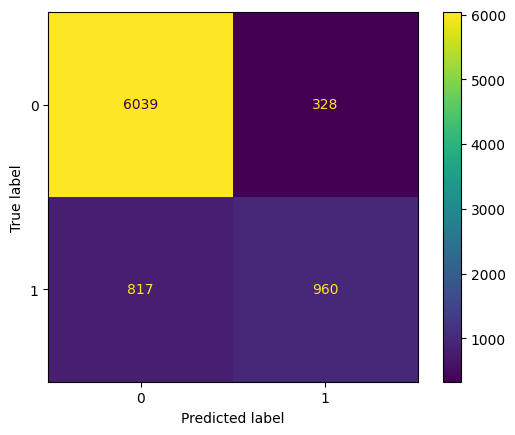


Classification Report:
              precision    recall  f1-score   support

           0      0.881     0.948     0.913      6367
           1      0.745     0.540     0.626      1777

    accuracy                          0.859      8144
   macro avg      0.813     0.744     0.770      8144
weighted avg      0.851     0.859     0.851      8144



In [53]:
print("\nConfusion Matrix:")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

In [42]:
ohe = clf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features = ohe.get_feature_names_out(feature_cat)

all_features = np.concatenate([feature_num, encoded_cat_features])
coefficients = clf.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": all_features,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

print("Top positive risk drivers:")
display(coef_df.head(10))

print("Top negative risk drivers:")
display(coef_df.tail(10).sort_values("coefficient"))

Top positive risk drivers:


,feature,coefficient
5,loan_to_income,1.766371
7,loan_grade_num,1.114850
12,person_home_ownership_RENT,0.464378
15,loan_intent_HOMEIMPROVEMENT,0.277101
10,person_home_ownership_OTHER,0.177298
13,loan_intent_DEBTCONSOLIDATION,0.152584
4,loan_int_rate,0.117168
0,person_income,0.107871
2,cb_person_cred_hist_length,-0.015025
1,person_emp_length,-0.030748


Top negative risk drivers:


,feature,coefficient
11,person_home_ownership_OWN,-1.921874
18,loan_intent_VENTURE,-0.900363
3,loan_amnt,-0.693236
14,loan_intent_EDUCATION,-0.671156
17,loan_intent_PERSONAL,-0.409720
6,interest_burden_pct_income,-0.374036
9,person_home_ownership_MORTGAGE,-0.317737
8,prior_default_flag,-0.047295
16,loan_intent_MEDICAL,-0.046380
1,person_emp_length,-0.030748


## 7. Underwriting Decision Simulation

The final step is to translate analytical results into a practical underwriting framework. In real lending environments, models do not make decisions on their own; instead, analysts combine **policy rules**, **risk metrics**, and **predicted default estimates** to guide approval decisions.

In this simulation, I use both:
- **risk tier**, based on loan-to-income ratio,
- **predicted probability of default (PD)** from the logistic regression model.

These two inputs are then mapped into three decision categories:
- **Approve** — lower-risk borrowers with low predicted default risk,
- **Manual Review** — borrowers with intermediate or mixed signals,
- **Reject** — borrowers showing clearly elevated risk by policy rule or model estimate.

This structure reflects how underwriting teams often separate straightforward approvals, borderline files that need analyst judgment, and applications that fall outside policy tolerance.

In [43]:
df["predicted_pd"] = clf.predict_proba(df[feature_num + feature_cat])[:, 1]

def underwriting_decision(row):
    if row["risk_tier"] == "High Risk" or row["predicted_pd"] >= 0.35:
        return "Reject"
    elif row["risk_tier"] == "Low Risk" and row["predicted_pd"] < 0.15 and row["prior_default_flag"] == 0:
        return "Approve"
    else:
        return "Manual Review"

df["underwriting_decision"] = df.apply(underwriting_decision, axis=1)

decision_summary = df.groupby("underwriting_decision").agg(
    borrower_count=("underwriting_decision", "count"),
    pct_of_portfolio=("underwriting_decision", lambda x: round(len(x) / len(df) * 100, 2)),
    observed_default_rate=("loan_status", lambda x: round(x.mean() * 100, 2)),
    avg_predicted_pd=("predicted_pd", lambda x: round(x.mean() * 100, 2))
)

display(decision_summary)

,borrower_count,pct_of_portfolio,observed_default_rate,avg_predicted_pd
underwriting_decision,,,,
Approve,11757,36.09,5.02,4.31
Manual Review,12867,39.50,12.78,14.54
Reject,7952,24.41,61.29,59.93


**Interpretation:**  
The decision summary shows clear separation in risk across the three underwriting outcomes. Approved borrowers have the lowest observed default rate, rejected borrowers have the highest, and manually reviewed files fall in the middle, which suggests the framework is directionally consistent with expected underwriting behavior.

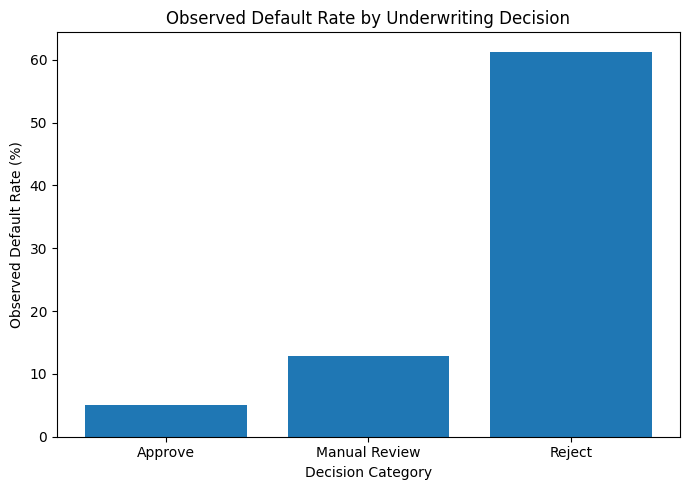

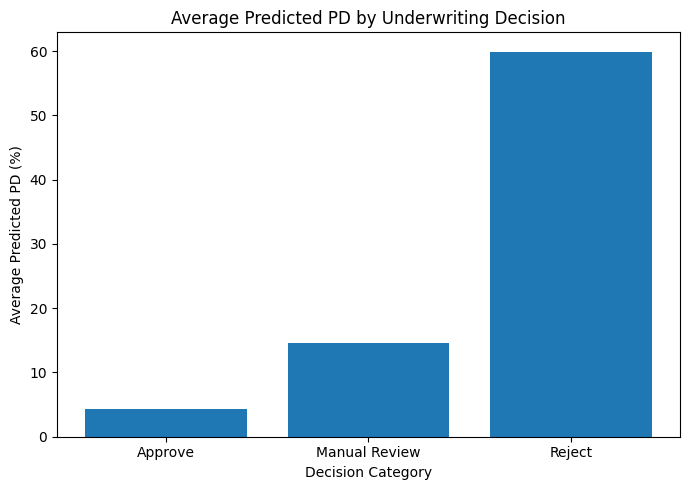

In [44]:
plt.figure(figsize=(7, 5))
plt.bar(decision_summary.index, decision_summary["observed_default_rate"])
plt.title("Observed Default Rate by Underwriting Decision")
plt.xlabel("Decision Category")
plt.ylabel("Observed Default Rate (%)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(decision_summary.index, decision_summary["avg_predicted_pd"])
plt.title("Average Predicted PD by Underwriting Decision")
plt.xlabel("Decision Category")
plt.ylabel("Average Predicted PD (%)")
plt.tight_layout()
plt.show()

**Interpretation:**  
Observed default rates differ materially across decision buckets, indicating that the simulation is successfully sorting borrowers by realized risk. This is a useful sign that the combined rule-based and model-based framework aligns with underlying borrower credit quality.

## 8. Expected Loss Analysis

Probability of default is useful for ranking borrower risk, but lenders also need to estimate the **economic impact** of that risk. To extend the analysis beyond classification, I calculate **Expected Loss (EL)** for each borrower using a simplified credit risk framework:

$$
Expected\ Loss = PD \times LGD \times EAD
$$

Where:
- **PD** = predicted probability of default from the logistic regression model,
- **LGD** = loss given default, assumed as a fixed percentage for this analysis,
- **EAD** = exposure at default, approximated using loan amount.

This framework is widely used in credit risk management because it combines borrower-level default risk with exposure size and loss severity. In this project, it provides a more complete view of portfolio risk by showing not just who is risky, but also where the bank is expected to lose the most money.

### Expected Loss Assumptions

Because the dataset does not contain collateral values, recovery history, or detailed balance information, I use simplified assumptions:

- **PD:** estimated from the logistic regression model  
- **EAD:** approximated by the original loan amount  
- **LGD:** assumed to be **45%** across borrowers for demonstration purposes  

This simplified EL approach is not intended to replicate regulatory capital modeling, but it is appropriate for illustrating how credit analysts can move from borrower classification to portfolio loss estimation.

In [ ]:
# Expected Loss (EL) Calculation

LGD = 0.45  # assumed constant LGD for illustrative underwriting analysis

df["ead"] = df["loan_amnt"]
df["lgd"] = LGD
df["expected_loss"] = df["predicted_pd"] * df["lgd"] * df["ead"]

# Borrower-level sample
display(
    df[[
        "loan_amnt",
        "predicted_pd",
        "lgd",
        "ead",
        "expected_loss",
        "risk_tier",
        "underwriting_decision"
    ]].head()
)

# Portfolio-level summary
portfolio_el_summary = pd.DataFrame({
    "metric": [
        "Total Exposure",
        "Average PD",
        "Average LGD",
        "Total Expected Loss",
        "Average Expected Loss per Borrower"
    ],
    "value": [
        df["ead"].sum(),
        df["predicted_pd"].mean(),
        df["lgd"].mean(),
        df["expected_loss"].sum(),
        df["expected_loss"].mean()
    ]
})

display(portfolio_el_summary)

# Expected loss by risk tier
el_by_risk_tier = df.groupby("risk_tier").agg(
    borrower_count=("risk_tier", "count"),
    total_exposure=("ead", "sum"),
    avg_pd=("predicted_pd", "mean"),
    total_expected_loss=("expected_loss", "sum"),
    avg_expected_loss=("expected_loss", "mean")
).round(2)

display(el_by_risk_tier)

# Expected loss by underwriting decision
el_by_decision = df.groupby("underwriting_decision").agg(
    borrower_count=("underwriting_decision", "count"),
    total_exposure=("ead", "sum"),
    avg_pd=("predicted_pd", "mean"),
    total_expected_loss=("expected_loss", "sum"),
    avg_expected_loss=("expected_loss", "mean")
).round(2)

display(el_by_decision)

,loan_amnt,predicted_pd,lgd,ead,expected_loss,risk_tier,underwriting_decision
0,29800,0.826426,0.45,29800,11082.378782,High Risk,Reject
1,1000,0.011503,0.45,1000,5.176494,Low Risk,Approve
2,5500,0.987813,0.45,5500,2444.836012,High Risk,Reject
3,29800,0.699848,0.45,29800,9384.967190,High Risk,Reject
4,29800,0.871336,0.45,29800,11684.620784,High Risk,Reject


,metric,value
0,Total Exposure,3.112998e+08
1,Average PD,2.192770e-01
2,Average LGD,4.500000e-01
3,Total Expected Loss,3.484585e+07
4,Average Expected Loss per Borrower,1.069679e+03


,borrower_count,total_exposure,avg_pd,total_expected_loss,avg_expected_loss
risk_tier,,,,,
High Risk,2317,37894975,0.65,10734474.28,4632.92
Low Risk,16468,106875825,0.11,4649962.83,282.36
Medium Risk,13791,166529050,0.28,19461415.46,1411.17


,borrower_count,total_exposure,avg_pd,total_expected_loss,avg_expected_loss
underwriting_decision,,,,,
Approve,11757,77578100,0.04,1400016.73,119.08
Manual Review,12867,140999675,0.15,8381817.72,651.42
Reject,7952,92722075,0.60,25064018.12,3151.91


**Interpretation:**  
Expected Loss adds an economic dimension to the analysis by translating borrower-level default risk into estimated portfolio loss. This helps identify not only which borrowers are riskier, but also which segments are likely to contribute the greatest financial loss.

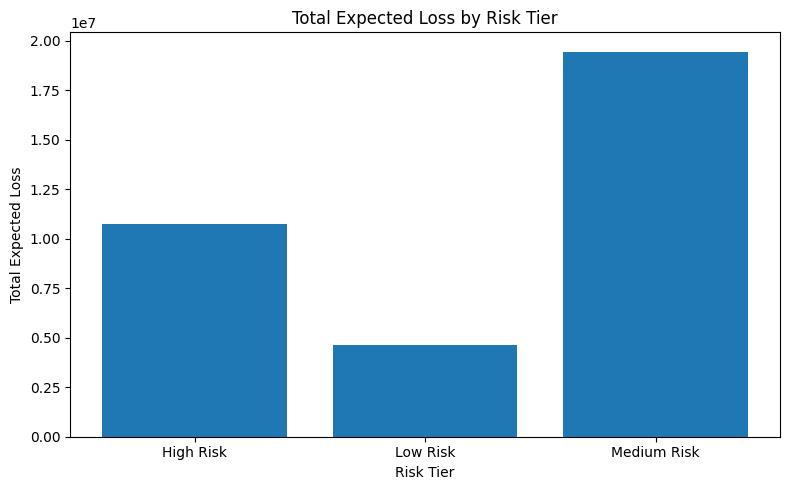

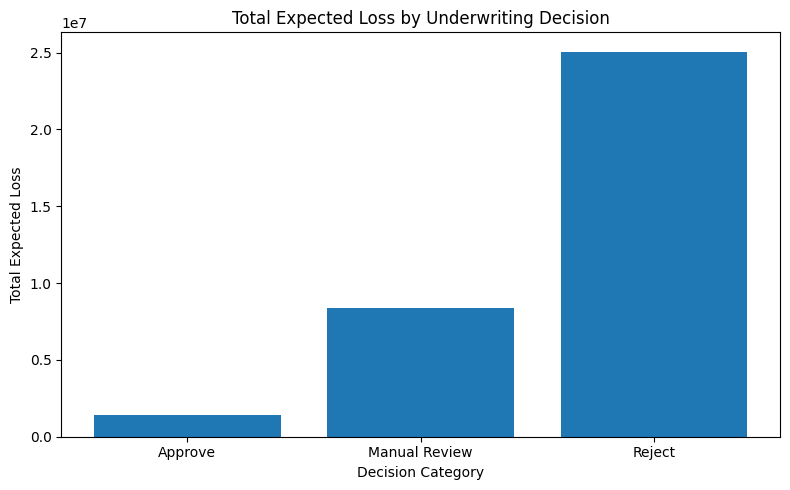

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(el_by_risk_tier.index.astype(str), el_by_risk_tier["total_expected_loss"])
plt.title("Total Expected Loss by Risk Tier")
plt.xlabel("Risk Tier")
plt.ylabel("Total Expected Loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(el_by_decision.index.astype(str), el_by_decision["total_expected_loss"])
plt.title("Total Expected Loss by Underwriting Decision")
plt.xlabel("Decision Category")
plt.ylabel("Total Expected Loss")
plt.tight_layout()
plt.show()

**Interpretation:**  
Higher-risk segments and rejected borrowers should contribute a disproportionately large share of expected loss because they combine weaker credit quality with higher predicted default probability. This makes Expected Loss especially useful for connecting underwriting policy to portfolio-level risk impact.

## 9. Conclusion

This project demonstrates how borrower-level loan data can be translated into a practical underwriting analysis that supports credit decisioning. By combining data cleaning, underwriting-oriented feature engineering, exploratory risk analysis, probability-of-default modeling, and a simple policy framework, the analysis produces results that are both interpretable and operationally useful.

### Key Findings
1. Borrowers with **lower income**, **larger loan exposure**, and **higher loan-to-income ratios** showed materially higher default risk.
2. **Loan-to-income ratio** emerged as one of the most useful underwriting variables for separating lower-risk and higher-risk borrowers.
3. The **logistic regression PD model** provided a transparent way to estimate borrower risk and supported decision-oriented segmentation.
4. The **Approve / Manual Review / Reject** simulation produced intuitive risk separation and illustrates how analytics can support real underwriting workflows.